# Fitting the model for motivational state

We will focus on the **Motivation level**: 
- 0: playing alone
- 1: easy rival
- 2: hard rival 

The data is now clustered by motivation level, i.e. `dataTrajecetories-25-M1-C1`. We are also splitting the dataset depending on the playing modes: passing through and stopping. For each dataset moreover we have the four different trajectories.

The data is normalized, clustered in terms of motivation, playing mode and ordered by trajectory. 

We are interested in having two different groups of fitted models:
1. First just clustered by subject, with all the motivational levels (and in fact all the modes) as if they were just one. This has already been done, when fitting the model for each subject, and getting the parameters. The only thing we are missing seems to be an accuracy metrics to compare the results with the following group of fits. However, the general just by subject is only conducted for the subject 25.
2. Then we want to consider different fits for each subject and each motivational level. Here we will get 3 fits for each subject. 

Hence, we get a total of 4 sets of fitted parameters for each subject that we should study how to compare. 

## General imports

In [1]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt

## Custom imports

In [26]:
# Get the current directory
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
folder = 'Implementation'
data_folder = os.path.join(parent_dir, folder)

# Construct the full file path
file_ = 'utils_data'
full_path = os.path.join(data_folder, file_)
print(full_path)
print(data_folder)
sys.path.append(data_folder)  

# Load the functions from .py file  
try:
    # Custom imports for loading and preprocessing the data
    from utils_data_multiple import point_to_segment, load_multiple_data, plot_multiple_data, cleaning_clustering_multiple_data
    from utils_data_multiple import saving_processed_mult_data, load_processed_mult_data, multiple_linear_transf
    
    # Custom imports for model fitting and parameter optimization
    from utils_model_multiple import load_params, box_plot_params, fitParamaters_mult

    # Custom imports for plotting and visualization
    from utils_model_multiple import plotting_dict_params, combined_multiple_trajectories_plot
    
    # Custom imports for fitting for the single subject 
    from utils_model import  fitParamaters
    #from utils_data import linear_transf
    #from utils_model import generate_trajectory, plot_simulation, generate_trajectory_vel, optimize_Sigma

    # Custom imports for fitting for the multiple subjects 
    from utils_data_multiple import get_cluster_data, get_cluster_idxrule, linear_transf 
    from utils_model_multiple import generate_trajectory, plot_simulation, generate_trajectory_vel, optimize_Sigma, saving_new_params
    
except ModuleNotFoundError as e:
    print("ModuleNotFoundError:", e)

c:\Users\Flavia\Documents\Flavia Python codes\MotorControlPrediction\Implementation\utils_data
c:\Users\Flavia\Documents\Flavia Python codes\MotorControlPrediction\Implementation


## Setting the parameters for the loading, preprocessing, fitting and inferring

Set the following parameters according to the study you wish to conduct: 
- `processing` when set to `True` it conducts the whole processing process from the raw data. This includes: 
    - `cleaning_clustering_multiple_data`: 
        - Cleaning the trajectories which do not cross the target and truncating the ones which do cross it. Also storing the optimal time in which they reach the target, $T^*$, stored in `idxrule` 
        - Classifying the data in 4 clusters, depending on the target they cross
    - `multiple_linear_transf`: 
        - Rotating the needed trajectories and scaling them in order to get normalized data
        - Computing the mean velocity and the velocity profiles for each trajectory

ATTENTION: This process takes more than 2 hours to be fully completed. 

- `fitting` when set to `True` the fitting of the parameters is conducted with the already processed data. This includes: 
    - `fitParamaters_mult`: 
        - Sequential approach: 
            1. Optimal movement duration: Generate the optimal trajectory by optimizing the Functional in terms of the time T 
            2. Optimal controller: generate the optimal trajectory with the optimal time duration by minimizing the functional in terms of the biomechanical parameters $(\alpha, \gamma, \varepsilon)$. 
            3. Stochastic optimization: generate the optimal trajectory with optimal time duration and biomechanical parameters by optimizing the Kolmogorov Sirnov estimate in terms of the sigma 
        - Saving the obtained parameters

We will load the preprocessed data, so we may consider the flag for processing as `False`. However, we want to fit the parameters according to the clusterings we want to consider:

In [3]:
processing = False
fitting = True
plotting = False
saving = False

## Loading multiple data

In [5]:
cluster_points = [
        (10.5, 4.85),   # pt2
        (-11, -5),       # pt3  
        (10.5, 0),      # pt1    
        (-10.5, 1.25)  # pt0
    ]
n_clusters = 4

segments = point_to_segment(cluster_points, n_clusters)

In [9]:
if processing:
    print('Loading and processing data...')
    data_dict = load_multiple_data(first_subj = 25, last_subj = 37, 
                       file_names = 'dataTrajectories' )
    if plotting: 
        print('List with al the target segments:', segments)
        print('List with the two points of segment for cluster 0:', segments[0])
        print('Array with point target 1 for cluster 0:', segments[0][0])
        print('First coordinate of point target 1 for cluster 0:', segments[0][0][0])
        plot_multiple_data(data_dict)
    
    cleaned_data_dict, idxrule_dict = cleaning_clustering_multiple_data(data_dict, 
                                    segments, 
                                    first_subj = 25, last_subj = 37,
                                    save_dir = 'subject_plots')

    if saving: 
        saving_processed_mult_data(idxrule_dict=idxrule_dict, folder_name='clustered_multiple_data')
        saving_processed_mult_data(cleaned_data_dict = cleaned_data_dict, 
                                folder_name = 'clustered_multiple_data')
        
    scaled_data_dict, velocity_dict, results_dict = multiple_linear_transf(cleaned_data_dict, idxrule_dict, 
                            segments, 
                            first_subj = 25, last_subj = 37,
                            n_clusters = 4,
                            saving = True, 
                            save_dir = 'subject_plots_2')
    if saving: 
        saving_processed_mult_data(cleaned_data_dict = scaled_data_dict, 
                                folder_name = 'scaled_data')
        saving_processed_mult_data(cleaned_data_dict = velocity_dict, 
                                folder_name = 'velocity')
        saving_processed_mult_data(idxrule_dict = results_dict, 
                                folder_name = 'scaled_data')
        
    print('Fitting paramaters for the optimized trajectory...')   

else:
    print('Loading processed data...')
    cleaned_data_dict, idxrule_dict = load_processed_mult_data(folder_name='clustered_multiple_data')
    scaled_data_dict, results_dict = load_processed_mult_data(folder_name='scaled_multiple_data') 
    print('Data loaded and processed :)')
    
    

Loading processed data...
Loading the cleaned data...
CSV and idxrule JSON files have been loaded successfully.
Loading the cleaned data...
CSV and idxrule JSON files have been loaded successfully.
Data loaded and processed :)


In [12]:
print("Loaded the following subjects:", scaled_data_dict.keys())
print("Each subject contains the following clustered data:", scaled_data_dict[25].keys())

Loaded the following subjects: dict_keys([25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36])
Each subject contains the following clustered data: dict_keys(['dfx_25_11_cluster_0', 'dfx_25_11_cluster_1', 'dfx_25_11_cluster_2', 'dfx_25_11_cluster_3', 'dfx_25_12_cluster_0', 'dfx_25_12_cluster_1', 'dfx_25_12_cluster_2', 'dfx_25_12_cluster_3', 'dfx_25_21_cluster_0', 'dfx_25_21_cluster_1', 'dfx_25_21_cluster_2', 'dfx_25_21_cluster_3', 'dfx_25_22_cluster_0', 'dfx_25_22_cluster_1', 'dfx_25_22_cluster_2', 'dfx_25_22_cluster_3', 'dfx_25_31_cluster_0', 'dfx_25_31_cluster_1', 'dfx_25_31_cluster_2', 'dfx_25_31_cluster_3', 'dfx_25_32_cluster_0', 'dfx_25_32_cluster_1', 'dfx_25_32_cluster_2', 'dfx_25_32_cluster_3', 'dfy_25_11_cluster_0', 'dfy_25_11_cluster_1', 'dfy_25_11_cluster_2', 'dfy_25_11_cluster_3', 'dfy_25_12_cluster_0', 'dfy_25_12_cluster_1', 'dfy_25_12_cluster_2', 'dfy_25_12_cluster_3', 'dfy_25_21_cluster_0', 'dfy_25_21_cluster_1', 'dfy_25_21_cluster_2', 'dfy_25_21_cluster_3', 'dfy_25_22_cluster

## Setting the clustered fittings of the set of parameters:

We have `fitParamaters` that fits the set of parameters per subject, regardless of the motivational level and mode, which is what we used for the single subject, getting the results from the Thesis. Then we have `fitParamaters_mult` that computes the fit actually getting a set of parameters per subject but also per motivational level and mode. 

Therefore, we need to implement `fitParamaters` for all the subjects (I think right now it is only implemented for the single subject 25), and get the first set of metrics for this configurations. 

Then, we need to implement a new custom `fitParamaters_mult` that just fits the model per subject and motivation (and not mode as the original one).

### Global fit for each subject (assuming one common motivational level)

In [19]:
#########################################
##          FITTING PARAMETERS         ##
#########################################

from typing import Tuple, List, Dict

def fitParamaters_motivation(scaled_data_dict: dict,
                  idxrule_dict: dict, 
                  results_dict: dict,
                  segments:  List[Tuple[Tuple[float, float], Tuple[float, float]]], 
                  first_subj: int = 25, last_subj: int = 37,
                  n_clusters = 4, 
                  folder_name = 'fitted_trajectories',
                  data_folder_name = 'fitted_parameters', 
                  saving = False, 
                  saving_data = True, 
                  motivational = False) -> Tuple[list, list]:
    
    '''
    Fit the parameters for each cluster based on the results and dataframes, for each subject.
    If motivational is True, it will fit the parameters for each motivational level and cluster.
    If motivational is False, it will fit the parameters for each cluster, assuming the motivational level is the same.
    '''
    
    new_params = {}
    opt_sigma = {}
    
     
    for subject in range(first_subj, last_subj):
        #print('Computing trajectory with optimized velocity for subject ', subject )
    
        if motivational:
            # Loop through each motivation level if motivational is True
            print(f'Fitting parameters for subject {subject}, clustered by motivational level')
            # Three runs per subject (motivation-specific), modes aggregated
            mot_partitions = [(f"mot{m}", [m]) for m in range(1, 4)]

        else:
            # Assuming common motivation level if motivational is False
            print(f'Fitting parameters for subject {subject}, assuming common motivational level')
            # Single run per subject (all motivations + all modes), aggregated
            mot_partitions = [("allMot", [1, 2, 3])]

        for mot_tag, mot_levels in mot_partitions:

            for cluster in range(n_clusters):
                    
                key_ = f'{subject}_{mot_tag}_cluster_{cluster}'

                # Initialize the dictionaries if not already
                if subject not in new_params:
                    new_params[subject] = {}
                if subject not in opt_sigma:
                    opt_sigma[subject] = {}
                    
                # ---- Aggregate data across ALL MODES (no mode loop for fitting) ----
                dfx, dfy, idxrule_combined, results_list = _collect_across_modes(
                    subject=subject, mot_levels=mot_levels, cluster=cluster
                )
                # --------------------------------------------------------------------

                if dfx.size == 0 or dfy.size == 0:
                    continue  # nothing to fit

                # ---- Step 1: optimize functional for time T ----

                ## Generate the optimal trajectory by optimizing the Functional in terms of the time T 
                x, y, T = generate_trajectory(plotting = False)
                plot_simulation(x, y, dfx, dfy, 
                            cluster = cluster, subject = subject, 
                            key_ = key_, 
                            pic_name = 'Trajectories_{mot_tag}', 
                            folder_name = folder_name,
                            saving_plot = saving)
                
                # ---- Step 2: optimize velocity parameters ----

                ## Generate the optimal trajectory with the time provided from optimizing the Functional 
                # by optimizing the velocity in terms of the parameters (alpha, epsilon, gamma)
                # Use the mean of available velocity results (results_list[*][1]) if present
                vel_candidates = []
                for r in results_list:
                    try:
                        vel_candidates.append(np.asarray(r[1]))
                    except Exception:
                        pass
                if vel_candidates:
                    vel_param = np.mean(np.stack(vel_candidates), axis=0)
                else:
                    # Fallback: zero or default vector if nothing available
                    vel_param = 0.0

                x_, y_, new_params[subject][key_] = generate_trajectory_vel(
                    plotting = False, 
                    T = T,
                    vel = vel_param
                )
                plot_simulation(
                    x_, y_, dfx, dfy, 
                    cluster = cluster,  subject = subject, 
                    key_ = key_, 
                    pic_name = 'Trajectories_optVel_{mot_tag}', 
                    folder_name = folder_name,
                    saving_plot = saving
                )
                
                # ---- Step 3: optimize sigma ----

                ## Generate the optimal trajectory with the optimum stopping time and parameters
                # by optimizing the Kolmogorov Sirnov estimate in terms of the sigma

                idxr = np.asarray(idxrule_combined)
                x__, y__, opt_sigma[subject][key_] = optimize_Sigma(
                    dfx, dfy,
                    idxrule = idxr, 
                    new_params = new_params[subject][key_]
                )
                plot_simulation(x__, y__, dfx, dfy, 
                                cluster = cluster,  subject = subject, 
                                key_ = key_, pic_name = 'Trajectories_optSigma_{mot_tag}', 
                                folder_name = folder_name,
                                saving_plot = saving)


    sigma_folder = f'{data_folder_name}_sigma'
    saving_new_params(new_params, folder_name= data_folder_name)
    saving_new_params(opt_sigma, folder_name= sigma_folder)
                    
    return new_params, opt_sigma



# Helper: collect data across ALL MODES for a given subject/motivation set/cluster
def _collect_across_modes(subject: int, mot_levels: List[int], cluster: int):
    dfx_list, dfy_list, idxrule_list, results_list = [], [], [], []

    for mot in mot_levels:
        for mode in (1, 2):
            dfx, dfy = get_cluster_data(scaled_data_dict, subject, mot, mode, cluster)
            idxrule = get_cluster_idxrule(idxrule_dict, subject, mot, mode, cluster)
            res = get_cluster_idxrule(results_dict, subject, mot, mode, cluster)

            if dfx is not None and not dfx.empty:
                dfx_list.append(dfx)
            if dfy is not None and not dfy.empty:
                dfy_list.append(dfy)
            if idxrule is not None and len(idxrule) > 0:
                idxrule_list.extend(idxrule)  # idxrule seems like a list/array, so we extend
            if res is not None:
                results_list.append(res)

    # Keep Pandas concatenation for dfx/dfy
    if dfx_list:
        combined_dfx = pd.concat(dfx_list, ignore_index=True)
    else:
        combined_dfx = pd.DataFrame()

    if dfy_list:
        combined_dfy = pd.concat(dfy_list, ignore_index=True)
    else:
        combined_dfy = pd.DataFrame()

    return combined_dfx, combined_dfy, idxrule_list, results_list


In [ ]:
def fitParamaters(results : pd.DataFrame, 
                  dfx : list, dfy : list, 
                  n_clusters = 4, 
                  plotting = True, saving = False, 
                  pic_name = 'Trajectories') -> Tuple[list, list]:
    """
    Fit the parameters for each cluster based on the results and dataframes, for each subject.
    This function generates the optimal trajectory by optimizing the Functional in terms of the time T, 
    """
    
    new_params = [[] for _ in range(n_clusters)]
    opt_sigma = [[] for _ in range(n_clusters)]
    
    for cluster in range(n_clusters): 
        
        print('Computing trajectory with optimized velocity for cluser: ', cluster)
        
        ## Generate the optimal trajectory by optimizing the Functional in terms of the time T 
        x, y, T, parameters_0 = generate_trajectory(plotting = False)
        if plotting:
            plot_simulation(x, y, dfx[cluster], dfy[cluster], 
                    cluster = cluster, pic_name = f'{pic_name}_optFunctional', 
                    saving_plot = saving)
        
        ## Generate the optimal trajectory with the time provided from optimizing the Functional 
        # by optimizing the velocity in terms of the parameters (alpha, epsilon, gamma)
        x_, y_, new_params[cluster] = generate_trajectory_vel(plotting = False, 
                                 T = T,
                                 vel = results[results['cluster'] == cluster].max_vel.values[0])
        if plotting:
            plot_simulation(x_, y_, dfx[cluster], dfy[cluster], 
                    cluster = cluster, pic_name = f'{pic_name}_optVel', 
                    saving_plot = saving)
        
        ## Generate the optimal trajectory with the optimum stopping time and parameters
        # by optimizing the Kolmogorov Sirnov estimate in terms of the sigma
            # Converting idxrule to array from string
        idxr = results[results['cluster'] == cluster].idxrule.values[0]
        idxrule = np.fromstring(idxr[1: -1], dtype = int, sep = ', ')
        
        x__, y__, opt_sigma[cluster] = optimize_Sigma(dfx[cluster] , dfy[cluster],
                                            idxrule = idxrule, 
                                            new_params = new_params[cluster])
        if plotting: 
            plot_simulation(x__, y__, dfx[cluster], dfy[cluster], 
                        cluster = cluster, pic_name = f'{pic_name}_optSigma', 
                        saving_plot = saving)
        
        print('Parameters estimated:')
        print(new_params[cluster].x, opt_sigma[cluster].x)
        
    return new_params, opt_sigma

### Clustered fit per subject and motivational level:

Fitting paramaters for the optimized trajectory...
Fitting parameters for subject 25, assuming common motivational level


c:\Users\Flavia\Documents\Flavia Python codes\MotorControlPrediction\Implementation\utils_model_multiple.py:211: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  xT_samples.append(dfx.loc[i][idxrule[i]-1])


Saving the new parameters...
Parameters JSON files have been saved successfully.
Saving the new parameters...
Parameters JSON files have been saved successfully.


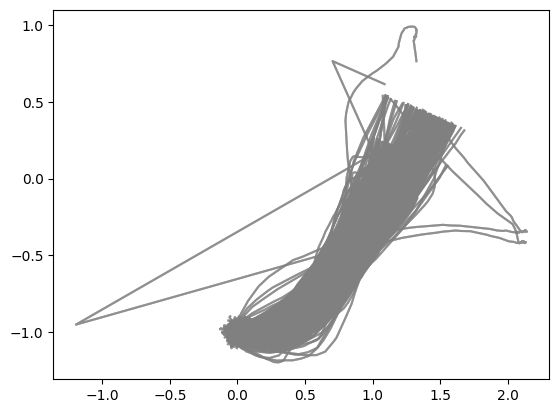

In [20]:
if fitting:
    # This is the regular fitting of the multiple parameters, by subject, 
    # motivational level, mode, and cluster
    print('Fitting paramaters for the optimized trajectory...')   
    new_params, opt_sigma = fitParamaters_motivation(scaled_data_dict,
                  idxrule_dict, 
                  results_dict,
                  segments, 
                  first_subj = 25, last_subj = 26,
                  n_clusters = 4, folder_name = 'fitted_pics', 
                  saving = saving, motivational=False)
    
else: 
    print('Loading fitted parameters...')
    params_loaded = load_params(folder_name = 'fitted_parameters')
    opt_sigma = load_params(folder_name = 'fitted_parameters_sigma')

$\gamma (s^{-1})$
T-test results:  TtestResult(statistic=np.float64(-0.7808343098489203), pvalue=np.float64(0.4378712117783402), df=np.float64(62.0))
$\gamma (s^{-1})$
Shapiro-Wilk test results: ShapiroResult(statistic=np.float64(0.9142745014261503), pvalue=np.float64(0.5053398915638745))
$\varepsilon (m^{-1} kg^{-2} s^{4})$
T-test results:  TtestResult(statistic=np.float64(-0.963728211905965), pvalue=np.float64(0.3389261394103701), df=np.float64(62.0))
$\varepsilon (m^{-1} kg^{-2} s^{4})$
Shapiro-Wilk test results: ShapiroResult(statistic=np.float64(0.9199687330575366), pvalue=np.float64(0.5367717386017167))
$\alpha (kg^{-1})$
T-test results:  TtestResult(statistic=np.float64(-2.1177805403022036), pvalue=np.float64(0.03821063185869757), df=np.float64(62.0))
$\alpha (kg^{-1})$
Shapiro-Wilk test results: ShapiroResult(statistic=np.float64(0.9232771495151729), pvalue=np.float64(0.5554726429803539))
$\sigma$
T-test results:  TtestResult(statistic=np.float64(0.7359601161405878), pvalue=np.

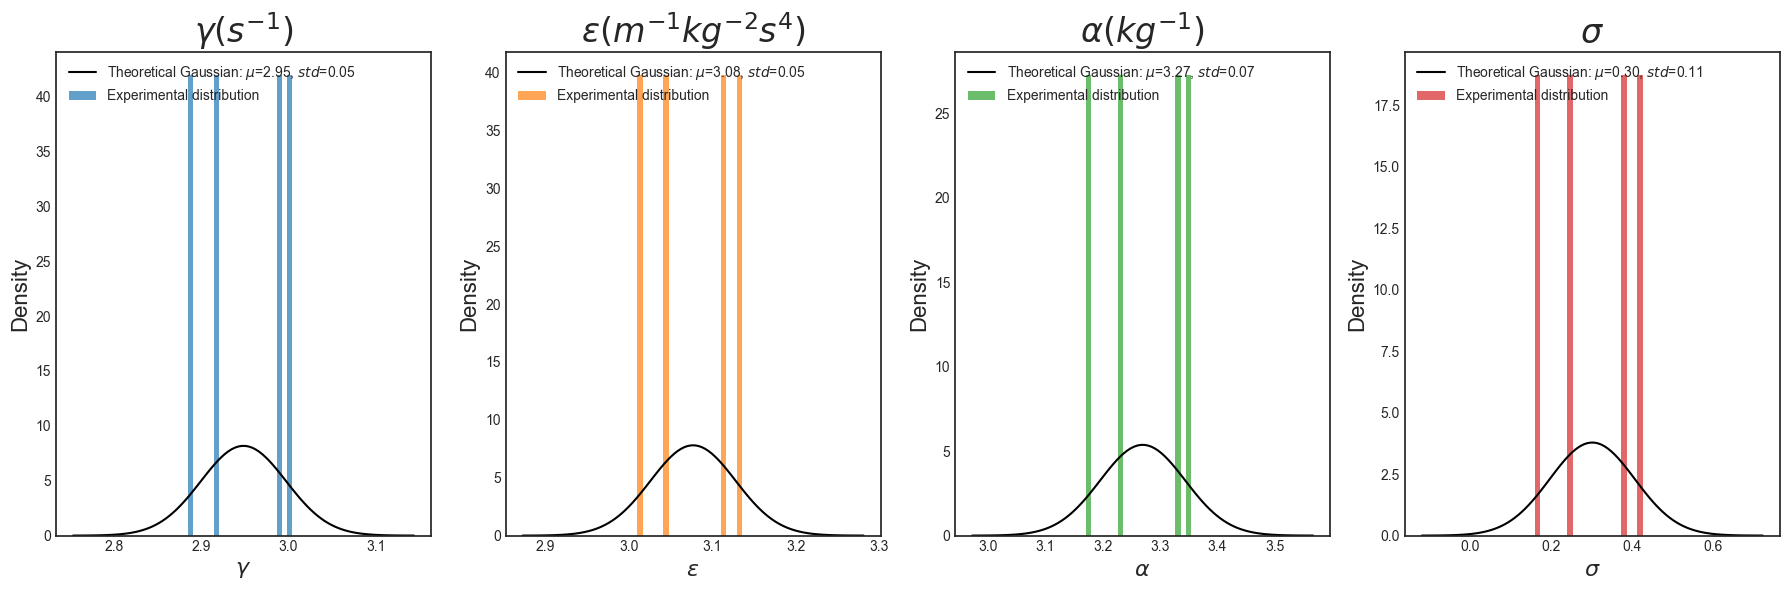

([TtestResult(statistic=np.float64(-0.7808343098489203), pvalue=np.float64(0.4378712117783402), df=np.float64(62.0)),
  TtestResult(statistic=np.float64(-0.963728211905965), pvalue=np.float64(0.3389261394103701), df=np.float64(62.0)),
  TtestResult(statistic=np.float64(-2.1177805403022036), pvalue=np.float64(0.03821063185869757), df=np.float64(62.0)),
  TtestResult(statistic=np.float64(0.7359601161405878), pvalue=np.float64(0.4645303225514116), df=np.float64(62.0))],
 [ShapiroResult(statistic=np.float64(0.9142745014261503), pvalue=np.float64(0.5053398915638745)),
  ShapiroResult(statistic=np.float64(0.9199687330575366), pvalue=np.float64(0.5367717386017167)),
  ShapiroResult(statistic=np.float64(0.9232771495151729), pvalue=np.float64(0.5554726429803539)),
  ShapiroResult(statistic=np.float64(0.9469534141298412), pvalue=np.float64(0.6971399443740159))],
 [np.float64(2.9485554154906866),
  np.float64(3.076918500738482),
  np.float64(3.269738966726943),
  np.float64(0.3012140103385346)],


In [27]:
plotting_dict_params(params_dict = new_params, opt_sigma = opt_sigma, 
                         barWidth=0.5, plotting_ = 1,
                         saving_plot = False, folder_name = 'fitted_pics', 
                         pic_name = 'parameters_gaussians_5')

In [25]:
print(new_params[25].keys())
new_params[25]['25_allMot_cluster_0'].x, opt_sigma[25]['25_allMot_cluster_0'].x  

dict_keys(['25_allMot_cluster_0', '25_allMot_cluster_1', '25_allMot_cluster_2', '25_allMot_cluster_3'])


(array([ 2.91799372,  3.04568802, -3.22674909]), np.float64(7.502694046998578))

## Setting the accuracy metrics that will be used

The function `compute_means_single_df` computes the mean coordinates for each cluster across all subjects in a single DataFrame. In this case, it computes the means of the metrics (the 4 metrics: `MSE, RMSE, DTW, MAE`) for each desired subject, among the 4 clusters, motivational levels and modes. Hence, we get the mean of the metrics between the estimated trajectories for each cluster, motivational level, mode and subject, getting the **Specific parameters** metrics we had at the Thesis. 